In [18]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
df = pd.read_csv('../../data/narc_data/merged_dataset_final_all.csv')
# -----------------------------
# 1. Features and Targets
# -----------------------------
X = df[['ph','organic_matter','total_nitrogen','potassium','p2o5',
    'zinc','sand','clay','slit','boron']]

y = df[['UREA1', 'DAP', 'MOP']]



In [19]:
df.columns

Index(['latitude', 'longitude', 'nearest_lat', 'nearest_lon', 'distance',
       'year', 'month', 'day', 'date', 'tp_mm', 't2m', 't2m_C',
       'anomaly_T2m_C', 'heat_stress_proxy', 'tp_7d_cum', 'tp_14d_cum',
       'tp_7d_avg', 'consec_rain_days', 'tp_lag1', 'tp_lag3', 'tp_lag7',
       'heavy_rain', 'month_sin', 'month_cos', 'heat_proxy', 'heat_next_day',
       'heat_next_2days', 'heat_next_3days', 'tp_anomaly', 'tp_std_anomaly',
       'heatwave_flag', 'next_day_match', 'next_2days_match',
       'next_3days_match', 'lat', 'lon', 'ph', 'organic_matter',
       'total_nitrogen', 'potassium', 'p2o5', 'boron', 'zinc', 'sand', 'clay',
       'slit', 'parentsoil', 'province', 'district', 'palika', 'crop',
       'variety', 'UREA1', 'UREA2', 'UREA3', 'DAP', 'MOP', 'organic',
       'boron_fert', 'palika_num'],
      dtype='object')

In [20]:

y_np = y.to_numpy()   # or y.values

for i, name in enumerate(y):
    vals = y_np[:, i]
    print(
        f"{name:5s} | "
        f"min={vals.min():.3f} | "
        f"mean={vals.mean():.3f} | "
        f"max={vals.max():.3f} | "
        f"std={vals.std():.3f}"
    )


UREA1 | min=0.970 | mean=1.367 | max=2.210 | std=0.361
DAP   | min=0.540 | mean=1.752 | max=3.620 | std=0.718
MOP   | min=1.250 | mean=1.687 | max=3.340 | std=0.420


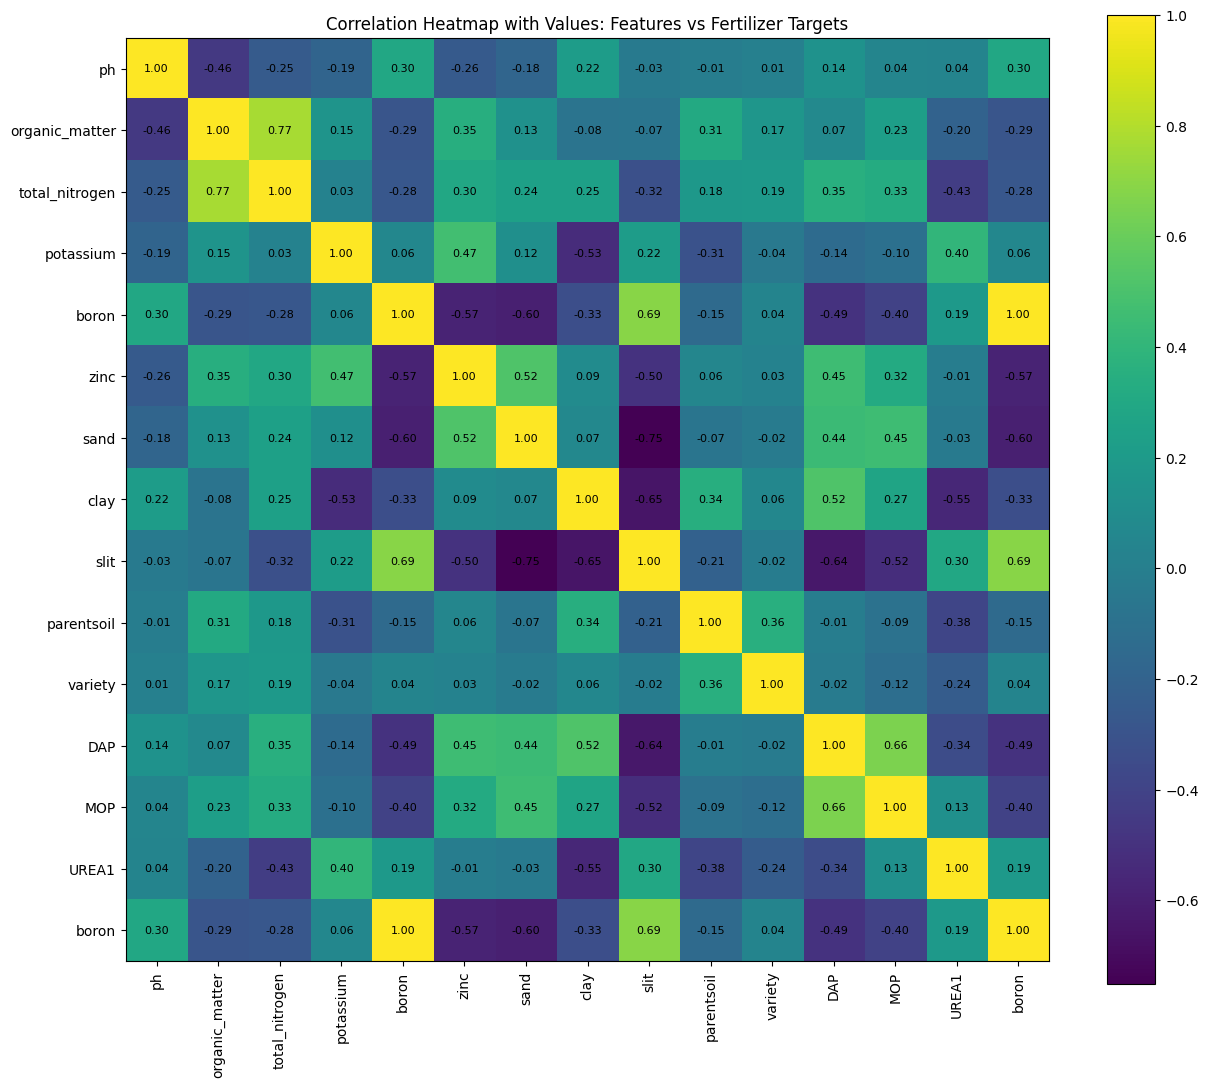

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Select columns
# -----------------------------
cols = [
    'ph', 'organic_matter','total_nitrogen', 'potassium',
        'boron','zinc', 'sand', 'clay', 'slit',
        'parentsoil', 'variety','DAP', 'MOP', 'UREA1', 'boron'
]

df_corr = df[cols].copy()

# Encode categorical variables
for col in ['parentsoil',  'variety']:
    df_corr[col] = df_corr[col].astype('category').cat.codes

# Correlation matrix
corr = df_corr.corr()

# -----------------------------
# Plot heatmap
# -----------------------------
plt.figure(figsize=(13, 11))
im = plt.imshow(corr)
plt.colorbar(im)

# Axis labels
plt.xticks(
    ticks=np.arange(len(corr.columns)),
    labels=corr.columns,
    rotation=90
)
plt.yticks(
    ticks=np.arange(len(corr.columns)),
    labels=corr.columns
)

# -----------------------------
# Annotate values in each cell
# -----------------------------
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        plt.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.title("Correlation Heatmap with Values: Features vs Fertilizer Targets")
plt.tight_layout()
plt.show()


In [22]:
df

,latitude,longitude,nearest_lat,nearest_lon,distance,year,month,day,date,tp_mm,...,crop,variety,UREA1,UREA2,UREA3,DAP,MOP,organic,boron_fert,palika_num
0,27.5,85.0,27.652,85.005,0.152082,2021,1,1,2021-01-01,0.0,...,0.0,0.0,1.72,1.93,1.93,0.54,1.67,6.0,1.0,1.0
1,27.5,85.0,27.652,85.005,0.152082,2021,1,2,2021-01-02,0.0,...,0.0,0.0,1.72,1.93,1.93,0.54,1.67,6.0,1.0,1.0
2,27.5,85.0,27.652,85.005,0.152082,2021,1,3,2021-01-03,0.0,...,0.0,0.0,1.72,1.93,1.93,0.54,1.67,6.0,1.0,1.0
3,27.5,85.0,27.652,85.005,0.152082,2021,1,4,2021-01-04,0.0,...,0.0,0.0,1.72,1.93,1.93,0.54,1.67,6.0,1.0,1.0
4,27.5,85.0,27.652,85.005,0.152082,2021,1,5,2021-01-05,0.0,...,0.0,0.0,1.72,1.93,1.93,0.54,1.67,6.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26470,28.0,86.0,27.892,85.476,0.535014,2025,10,27,2025-10-27,0.0,...,0.0,1.0,0.97,1.81,1.81,2.17,1.67,6.0,1.0,NaN
26471,28.0,86.0,27.892,85.476,0.535014,2025,10,28,2025-10-28,0.0,...,0.0,1.0,0.97,1.81,1.81,2.17,1.67,6.0,1.0,NaN
26472,28.0,86.0,27.892,85.476,0.535014,2025,10,29,2025-10-29,0.0,...,0.0,1.0,0.97,1.81,1.81,2.17,1.67,6.0,1.0,NaN
26473,28.0,86.0,27.892,85.476,0.535014,2025,10,30,2025-10-30,0.0,...,0.0,1.0,0.97,1.81,1.81,2.17,1.67,6.0,1.0,NaN


In [23]:
df.drop(columns='palika_num', inplace=True)
df.drop(columns='district', inplace=True)
df.drop(columns='province', inplace=True)
df.drop(columns='palika', inplace=True)



In [24]:
df.dtypes

latitude             float64
longitude            float64
nearest_lat          float64
nearest_lon          float64
distance             float64
year                   int64
month                  int64
day                    int64
date                  object
tp_mm                float64
t2m                  float64
t2m_C                float64
anomaly_T2m_C        float64
heat_stress_proxy      int64
tp_7d_cum            float64
tp_14d_cum           float64
tp_7d_avg            float64
consec_rain_days       int64
tp_lag1              float64
tp_lag3              float64
tp_lag7              float64
heavy_rain             int64
month_sin            float64
month_cos            float64
heat_proxy             int64
heat_next_day          int64
heat_next_2days        int64
heat_next_3days        int64
tp_anomaly           float64
tp_std_anomaly       float64
heatwave_flag          int64
next_day_match          bool
next_2days_match        bool
next_3days_match        bool
lat           

In [25]:
# -----------------------------
# 2. Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 3. Pipeline (Scaler + RF)
# -----------------------------
rf_base = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", MultiOutputRegressor(rf_base))
])

# -----------------------------
# 4. Training
# -----------------------------
model.fit(X_train, y_train)

# -----------------------------
# 5. Predictions
# -----------------------------
y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

# -----------------------------
# 6. Evaluation Function
# -----------------------------
def evaluate(y_true, y_pred, split_name):
    print(f"\n===== {split_name} Evaluation =====")

    mse = mean_squared_error(y_true, y_pred, multioutput='raw_values')
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred, multioutput='raw_values')
    r2 = r2_score(y_true, y_pred, multioutput='raw_values')

    metrics_df = pd.DataFrame({
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }, index=y.columns)

    print(metrics_df)

    print("\n-- Overall (macro average) --")
    print(f"RMSE: {rmse.mean():.4f}")
    print(f"MAE : {mae.mean():.4f}")
    print(f"R2  : {r2.mean():.4f}")

# -----------------------------
# 7. Training-set Metrics
# -----------------------------
evaluate(y_train, y_train_pred, "Training Set")

# -----------------------------
# 8. Testing-set Metrics
# -----------------------------
evaluate(y_test, y_test_pred, "Testing Set")



===== Training Set Evaluation =====
               RMSE           MAE        R2
UREA1  5.883961e-04  5.701133e-06  0.999997
DAP    2.747261e-14  2.147489e-14  1.000000
MOP    6.184143e-06  4.249293e-08  1.000000

-- Overall (macro average) --
RMSE: 0.0002
MAE : 0.0000
R2  : 1.0000

===== Testing Set Evaluation =====
               RMSE           MAE        R2
UREA1  1.924455e-03  4.580737e-05  0.999972
DAP    2.715310e-14  2.116917e-14  1.000000
MOP    2.142250e-05  5.099150e-07  1.000000

-- Overall (macro average) --
RMSE: 0.0006
MAE : 0.0000
R2  : 1.0000


The near-perfect performance for UREA, DAP, and MOP is expected because these fertilizer recommendations are directly derived from total nitrogen (N), phosphorus (P), and potassium (K) through deterministic agronomic formulas, which introduces an inherent dependency between inputs and targets; as a result, the testing set follows the same functional relationship as the training data, leading to very similar error metrics, which motivates the use of Reinforcement Learning with Proximal Policy Optimization (RL-PPO) rather than a purely static regression model.